In [129]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda") # Google Colab GPU
elif torch.backends.mps.is_available():
    device = torch.device("mps") # Mac GPU
else:
    device = torch.device("cpu") # CPU
    
print(device)

mps


# Importing Data

In [130]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from datasets import load_dataset

def import_test_variant(path):
    return datasets.ImageFolder(root=path, transform=test_transform)

def transform_train(huggingface):
    huggingface["pixel_values"] = [train_transform(image.convert("RGB")) for image in huggingface["image"]]
    return huggingface

# Main dataset
food = load_dataset("ethz/food101")

# Training set
train = food['train'].with_transform(transform_train)
# DO NOT USE food['validation'] for test data, use test_clean instead

# Used to transform training data
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224), # Random crop and resize to 224x224 px, for robustness
    transforms.RandomHorizontalFlip(), # Random 50% flip, for robustness
    transforms.ToTensor(), # Convert image (0-255) into 0.0-1.0
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Standard values
])

# Used to transform test data
test_transform = transforms.Compose([
    transforms.Resize(256), # Bigger than 224 so crop ensures food fills image
    transforms.CenterCrop(224), # Same size as the train_transform crop
    transforms.ToTensor(), # Convert image (0-255) into 0.0-1.0
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Standard values
])

test_directory = "test_splits"
model_directory = "models"
evaluation_directory = "evaluations" 

# Test variant paths in Google Drive
clean_path = f'{test_directory}/clean'
blur_little_path = f'{test_directory}/blur_little'
blur_medium_path = f'{test_directory}/blur_medium'
downsampled_path = f'{test_directory}/downsampled'
masked_path = f'{test_directory}/masked'
noise_rotation_path = f'{test_directory}/noise_rotation'

# Final test variants
test_clean = import_test_variant(clean_path)
test_blur_little = import_test_variant(blur_little_path)
test_blur_medium = import_test_variant(blur_medium_path)
test_downsampled = import_test_variant(downsampled_path)
test_masked = import_test_variant(masked_path)
test_noise_rotation = import_test_variant(noise_rotation_path)

test_sets = {
    "Clean": test_clean,
    "Blur_Little": test_blur_little,
    "Blur_Medium": test_blur_medium,
    "Downsampled": test_downsampled,
    "Masked": test_masked,
    "Noise_Rotation": test_noise_rotation
}

print("\nData import complete")


Data import complete


# Exploration

In [131]:
print("DATASET SIZES")
print()
print(f"Training: {len(train)}")
print(f"Test (Clean): {len(test_clean)}")
print()
print(f"Test (Blur Little): {len(test_blur_little)}")
print(f"Test (Blur Medium): {len(test_blur_medium)}")
print(f"Test (Downsampled): {len(test_downsampled)}")
print(f"Test (Masked): {len(test_masked)}")
print(f"Test (Noise Rotation): {len(test_noise_rotation)}")

DATASET SIZES

Training: 75750
Test (Clean): 25250

Test (Blur Little): 25250
Test (Blur Medium): 25250
Test (Downsampled): 25250
Test (Masked): 25250
Test (Noise Rotation): 25250


In [132]:
food_classes = test_clean.classes

for i in range(0, len(food_classes), 5):
    print(', '.join(food_classes[i : i+5]))

apple_pie, baby_back_ribs, baklava, beef_carpaccio, beef_tartare
beet_salad, beignets, bibimbap, bread_pudding, breakfast_burrito
bruschetta, caesar_salad, cannoli, caprese_salad, carrot_cake
ceviche, cheese_plate, cheesecake, chicken_curry, chicken_quesadilla
chicken_wings, chocolate_cake, chocolate_mousse, churros, clam_chowder
club_sandwich, crab_cakes, creme_brulee, croque_madame, cup_cakes
deviled_eggs, donuts, dumplings, edamame, eggs_benedict
escargots, falafel, filet_mignon, fish_and_chips, foie_gras
french_fries, french_onion_soup, french_toast, fried_calamari, fried_rice
frozen_yogurt, garlic_bread, gnocchi, greek_salad, grilled_cheese_sandwich
grilled_salmon, guacamole, gyoza, hamburger, hot_and_sour_soup
hot_dog, huevos_rancheros, hummus, ice_cream, lasagna
lobster_bisque, lobster_roll_sandwich, macaroni_and_cheese, macarons, miso_soup
mussels, nachos, omelette, onion_rings, oysters
pad_thai, paella, pancakes, panna_cotta, peking_duck
pho, pizza, pork_chop, poutine, prime_r

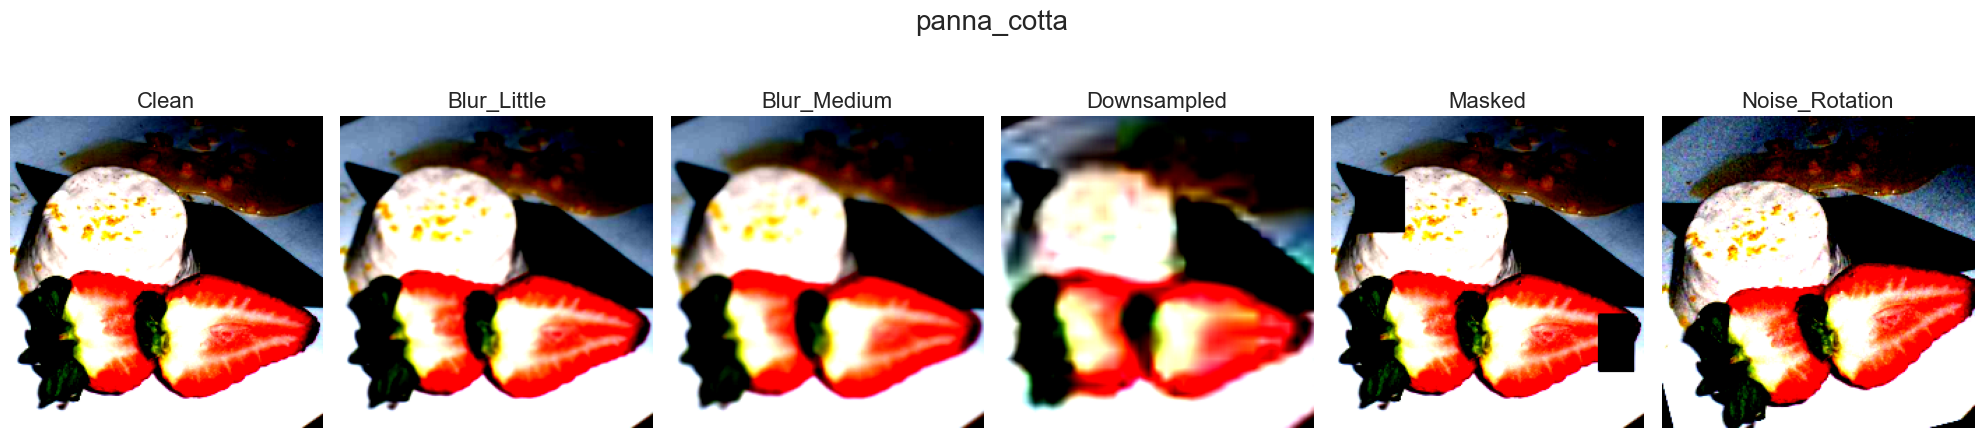

In [133]:
# This block of code shows all variants of a random test image (after applying transformer).

import matplotlib.pyplot as plt
import numpy as np
import random

# Getting random test index and the assocoiated class name
random_idx = random.randint(0, len(test_sets["Clean"]) - 1)
_, label_idx = test_sets["Clean"][random_idx]
class_name = test_sets["Clean"].classes[label_idx]

# Plotting
fig, axes = plt.subplots(1, len(test_sets), figsize=(20, 5))

for i, (name, test_set) in enumerate(test_sets.items()):

    # Tensor to image
    img_tensor, _ = test_set[random_idx]
    img = img_tensor.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    # Adding image for variant
    axes[i].imshow(img)
    axes[i].set_title(name, fontsize=16)
    axes[i].axis('off')

fig.suptitle(f"{class_name}", fontsize=20)
plt.tight_layout()
plt.show()

# Backbone

In [134]:
import torch.nn as nn
from torchvision import models

# Number of classes of food in the dataset
num_classes = len(food_classes)

# ResNet18
resnet = models.resnet18(weights='IMAGENET1K_V1')
# Adjust the output layer for the specific number of classes
num_ftrs_res = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs_res, num_classes)

# EfficientNetV2-S
effnet = models.efficientnet_v2_s(weights='IMAGENET1K_V1')
# Adjust the output layer for the specific number of classes
num_ftrs_eff = effnet.classifier[1].in_features
effnet.classifier[1] = nn.Linear(num_ftrs_eff, num_classes)

In [135]:
resnet_baseline_path = model_directory + '/resnet_baseline.pth'
effnet_baseline_path = model_directory + '/effnet_baseline.pth'

resnet_lora_path = model_directory + '/resnet_lora.pth'
effnet_lora_path = model_directory + '/effnet_lora.pth'

resnet_adapter_path = model_directory + '/resnet_adapter.pth'
effnet_adapter_path = model_directory + '/effnet_adapter.pth'

In [136]:
import pandas as pd

def train_model(model, model_name, optimizer):

    n_epochs = 5
    loss_function = nn.CrossEntropyLoss()
    
    # Initialize lists
    train_acc_list = []
    valid_acc_list = []
    train_loss_list = []
    valid_loss_list = []

    model.to(device)

    for epoch in range(n_epochs):
        
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = loss_function(output, target)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * data.size(0)
            _, predicted = torch.max(output.data, 1)
            train_correct += (predicted == target).sum().item()
            
        # Validation
        model.eval()
        valid_loss = 0.0
        valid_correct = 0
        
        with torch.no_grad():
            for data, target in test_clean_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = loss_function(output, target)
                
                valid_loss += loss.item() * data.size(0)
                _, predicted = torch.max(output.data, 1)
                valid_correct += (predicted == target).sum().item()

        # Calculate Averages
        train_loss = train_loss/len(train_loader.dataset)
        train_acc = train_correct/len(train_loader.dataset)
        valid_loss = valid_loss/len(test_clean_loader.dataset)
        valid_acc = valid_correct/len(test_clean_loader.dataset)

        # Print values after each epoch
        print(f'Epoch {epoch+1}/{n_epochs}:')
        print(f'\tTrain Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}')
        print(f'\tValidation Loss: {valid_loss:.4f} | Validation Accuracy: {valid_acc:.4f}')

        # Add values to lists for plotting
        train_loss_list.append(train_loss)
        train_acc_list.append(train_acc)
        valid_loss_list.append(valid_loss)
        valid_acc_list.append(valid_acc)

    history = pd.DataFrame({
        'train_loss': train_loss_list,
        'train_accuracy': train_acc_list,
        'valid_loss': valid_loss_list,
        'valid_accuracy': valid_acc_list
    })
    
    history.to_csv(f'{evaluation_directory}/{model_name}_training_history.csv', index=False)
    print()

def collate(images):
    pixel_values = torch.stack([image["pixel_values"] for image in images])
    labels = torch.tensor([image["label"] for image in images])
    return pixel_values, labels

batch_size = 32
train_loader = DataLoader(train, batch_size=batch_size, shuffle=True, collate_fn=collate, num_workers=0)
test_clean_loader = DataLoader(test_clean, batch_size=batch_size, shuffle=False, num_workers=0)

## 1 - Linear Probing (Baseline)

In [113]:
import copy

def freeze_all_layers(model):
    for param in model.parameters():
        param.requires_grad = False

def get_linear_probe_model_resnet():

    resnet_model = copy.deepcopy(resnet)
    freeze_all_layers(resnet_model)
    resnet_model.fc.weight.requires_grad = True
    resnet_model.fc.bias.requires_grad = True

    return resnet_model

def get_linear_probe_model_effnet():

    effnet_model = copy.deepcopy(effnet)
    freeze_all_layers(effnet_model)
    effnet_model.classifier[1].weight.requires_grad = True
    effnet_model.classifier[1].bias.requires_grad = True

    return effnet_model

resnet_baseline = get_linear_probe_model_resnet()
effnet_baseline = get_linear_probe_model_effnet()

In [10]:
resnet_baseline.to(device) # To GPU
optimizer_resnet_baseline = torch.optim.Adam(filter(lambda p: p.requires_grad, resnet_baseline.parameters()), lr=1e-4)
train_model(resnet_baseline, "resnet_baseline", optimizer_resnet_baseline) # Training model
torch.save(resnet_baseline.state_dict(), resnet_baseline_path) # Saving model

effnet_baseline.to(device) # To GPU
optimizer_effnet_baseline = torch.optim.Adam(filter(lambda p: p.requires_grad, effnet_baseline.parameters()), lr=1e-4)
train_model(effnet_baseline, "effnet_baseline", optimizer_effnet_baseline) # Training model
torch.save(effnet_baseline.state_dict(), effnet_baseline_path) # Saving model

/opt/anaconda3/lib/python3.13/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1/5:
	Train Loss: 4.2206 | Train Accuracy: 0.1156
	Validation Loss: 3.6423 | Validation Accuracy: 0.2744
Epoch 2/5:
	Train Loss: 3.5218 | Train Accuracy: 0.2860
	Validation Loss: 3.0294 | Validation Accuracy: 0.3952
Epoch 3/5:
	Train Loss: 3.1157 | Train Accuracy: 0.3514
	Validation Loss: 2.6766 | Validation Accuracy: 0.4394
Epoch 4/5:
	Train Loss: 2.8743 | Train Accuracy: 0.3850
	Validation Loss: 2.4494 | Validation Accuracy: 0.4741
Epoch 5/5:
	Train Loss: 2.7094 | Train Accuracy: 0.4048
	Validation Loss: 2.2975 | Validation Accuracy: 0.4920

Epoch 1/5:
	Train Loss: 4.2537 | Train Accuracy: 0.1502
	Validation Loss: 3.7791 | Validation Accuracy: 0.3391
Epoch 2/5:
	Train Loss: 3.6832 | Train Accuracy: 0.2897
	Validation Loss: 3.2391 | Validation Accuracy: 0.3882
Epoch 3/5:
	Train Loss: 3.3260 | Train Accuracy: 0.3247
	Validation Loss: 2.8949 | Validation Accuracy: 0.4173
Epoch 4/5:
	Train Loss: 3.1051 | Train Accuracy: 0.3444
	Validation Loss: 2.6821 | Validation Accuracy: 0.4372


## 2 - LoRA

In [118]:
import loralib as lora 

def apply_lora(model, rank=8, alpha=16):
    
    # Freeze all current parameters
    for param in model.parameters():
        param.requires_grad = False

    model_modules = dict(model.named_modules())
    
    for name, module in model_modules.items():
        if name == 'fc' or 'classifier' in name or 'head' in name:
            continue
            
        new_layer = None
        
        if isinstance(module, nn.Linear):
            new_layer = lora.Linear(
                module.in_features, 
                module.out_features, 
                r=rank, 
                lora_alpha=alpha
            )
            new_layer.weight.data = module.weight.data.clone()
            if module.bias is not None:
                new_layer.bias.data = module.bias.data.clone()
        
        elif isinstance(module, nn.Conv2d):

            k_size = module.kernel_size[0] if isinstance(module.kernel_size, tuple) else module.kernel_size
            
            new_layer = lora.Conv2d(
                module.in_channels, 
                module.out_channels, 
                kernel_size=k_size, 
                r=rank, 
                lora_alpha=alpha,
                stride=module.stride,
                padding=module.padding,
                groups=module.groups,
                bias=(module.bias is not None)
            )
            
            # Handle version-specific weight location
            if hasattr(new_layer, 'weight'):
                new_layer.weight.data = module.weight.data.clone()
                if module.bias is not None:
                    new_layer.bias.data = module.bias.data.clone()
            else:
                new_layer.conv.weight.data = module.weight.data.clone()
                if module.bias is not None:
                    new_layer.conv.bias.data = module.bias.data.clone()

        if new_layer:
            new_layer.to(next(module.parameters()).device)
            parent_name = name.rsplit('.', 1)[0] if '.' in name else ''
            child_name = name.split('.')[-1]
            if parent_name:
                setattr(model_modules[parent_name], child_name, new_layer)
            else:
                setattr(model, child_name, new_layer)

    # Mark LoRA parameters as trainable
    lora.mark_only_lora_as_trainable(model)
    
    # Re-enable final classification head
    if hasattr(model, 'fc'):
        for param in model.fc.parameters():
            param.requires_grad = True
    if hasattr(model, 'classifier'):
        for param in model.classifier.parameters():
            param.requires_grad = True
            
    return model

def get_lora_model_resnet():
    model = copy.deepcopy(resnet)
    return apply_lora(model)

def get_lora_model_effnet():
    model = copy.deepcopy(effnet)
    return apply_lora(model)

resnet_lora = get_lora_model_resnet()
effnet_lora = get_lora_model_effnet()

In [119]:
resnet_lora.to(device) # To GPU
optimizer_resnet_lora = torch.optim.Adam(filter(lambda p: p.requires_grad, resnet_lora.parameters()), lr=1e-4)
train_model(resnet_lora, "resnet_lora", optimizer_resnet_lora) # Training model
torch.save(resnet_lora.state_dict(), resnet_lora_path) # Saving model

effnet_lora.to(device) # To GPU
optimizer_effnet_lora = torch.optim.Adam(filter(lambda p: p.requires_grad, effnet_lora.parameters()), lr=1e-4)
train_model(effnet_lora, "effnet_lora", optimizer_effnet_lora) # Training model
torch.save(effnet_lora.state_dict(), effnet_lora_path) # Saving model

Epoch 1/5:
	Train Loss: 2.6099 | Train Accuracy: 0.4081
	Validation Loss: 1.2173 | Validation Accuracy: 0.7082
Epoch 2/5:
	Train Loss: 1.5250 | Train Accuracy: 0.6158
	Validation Loss: 0.8813 | Validation Accuracy: 0.7686
Epoch 3/5:
	Train Loss: 1.3152 | Train Accuracy: 0.6635
	Validation Loss: 0.7864 | Validation Accuracy: 0.7989
Epoch 4/5:
	Train Loss: 1.1929 | Train Accuracy: 0.6907
	Validation Loss: 0.7426 | Validation Accuracy: 0.8128
Epoch 5/5:
	Train Loss: 1.1168 | Train Accuracy: 0.7100
	Validation Loss: 0.7074 | Validation Accuracy: 0.8218



## 3 - Task-Specific Adapters

In [68]:
class FoodAdapter(nn.Module):
    def __init__(self, channels, bottleneck_dim=64):
        super(FoodAdapter, self).__init__()
        
        self.adapter = nn.Sequential(
            nn.Linear(channels, bottleneck_dim),
            nn.ReLU(inplace=True),
            nn.Linear(bottleneck_dim, channels)
        )
        nn.init.zeros_(self.adapter[-1].weight)
        nn.init.zeros_(self.adapter[-1].bias)

    def forward(self, x):
        if x.dim() == 4:
            residual = x
            x = x.permute(0, 2, 3, 1) 
            x = self.adapter(x)
            x = x.permute(0, 3, 1, 2)
            return residual + x
        return x + self.adapter(x)

class AdaptedLayer(nn.Module):
    def __init__(self, original_layer, channels, bottleneck_dim=64):
        super(AdaptedLayer, self).__init__()
        self.original_layer = original_layer
        self.adapter = FoodAdapter(channels, bottleneck_dim)

    def forward(self, x):
        x = self.original_layer(x)
        return self.adapter(x)

def apply_adapters(model, model_type="resnet", bottleneck=128): # Increased bottleneck
    device = next(model.parameters()).device
    for param in model.parameters():
        param.requires_grad = False

    if model_type == "resnet":
        for i in range(len(model.layer4)):
            model.layer4[i].bn2 = AdaptedLayer(model.layer4[i].bn2, 512, bottleneck).to(device)

        for param in model.fc.parameters():
            param.requires_grad = True

    elif model_type == "effnet":
        for i in range(1, 5):
            target = model.features[-i]
            for module in target.modules():
                if isinstance(module, nn.Conv2d):
                    channels = module.out_channels
            
            model.features[-i] = AdaptedLayer(target, channels, bottleneck).to(device)
        
        for param in model.classifier.parameters():
            param.requires_grad = True

    return model

def get_adapter_model_resnet():
    model = copy.deepcopy(resnet)
    return apply_adapters(model, model_type="resnet")

def get_adapter_model_effnet():
    model = copy.deepcopy(effnet)
    return apply_adapters(model, model_type="effnet")

resnet_adapter = get_adapter_model_resnet()
effnet_adapter = get_adapter_model_effnet()

In [70]:
resnet_adapter.to(device) # To GPU
optimizer_resnet_adapter = torch.optim.Adam(filter(lambda p: p.requires_grad, resnet_adapter.parameters()), lr=1e-4)
train_model(resnet_adapter, "resnet_adapter", optimizer_resnet_adapter) # Training model
torch.save(resnet_adapter.state_dict(), resnet_adapter_path) # Saving model

effnet_adapter.to(device) # To GPU
optimizer_effnet_adapter = torch.optim.Adam(filter(lambda p: p.requires_grad, effnet_adapter.parameters()), lr=1e-4)
train_model(effnet_adapter, "effnet_adapter", optimizer_effnet_adapter) # Training model
torch.save(effnet_adapter.state_dict(), effnet_adapter_path) # Saving model

Epoch 1/5:
	Train Loss: 3.5240 | Train Accuracy: 0.2174
	Validation Loss: 2.1979 | Validation Accuracy: 0.4673
Epoch 2/5:
	Train Loss: 2.4325 | Train Accuracy: 0.4134
	Validation Loss: 1.7352 | Validation Accuracy: 0.5564
Epoch 3/5:
	Train Loss: 2.1197 | Train Accuracy: 0.4755
	Validation Loss: 1.5098 | Validation Accuracy: 0.6090
Epoch 4/5:
	Train Loss: 1.9554 | Train Accuracy: 0.5120
	Validation Loss: 1.3924 | Validation Accuracy: 0.6410
Epoch 5/5:
	Train Loss: 1.8484 | Train Accuracy: 0.5372
	Validation Loss: 1.2967 | Validation Accuracy: 0.6606



# Model Evaluation

In [123]:
# Add any models you create
model_paths_to_evaluate = {
    "resnet_baseline": resnet_baseline_path,
    "effnet_baseline": effnet_baseline_path,
    "resnet_lora": resnet_lora_path,
    "effnet_lora": effnet_lora_path,
    "resnet_adapter": resnet_adapter_path,
    "effnet_adapter": effnet_adapter_path
}

In [121]:
import time
from thop import profile

def evaluate(model, dataset):
    
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    correct = 0
    total = 0
    
    start_time = time.time()
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    end_time = time.time()
    
    avg_accuracy = correct / total
    evaluation_time = end_time - start_time
    inference_speed = evaluation_time / total # Time per image

    return avg_accuracy, inference_speed

# Determining accuracy for each model for each test variant
for model_name, model_path in model_paths_to_evaluate.items():

    model_evaluations = []

    match model_name:
        case "resnet_baseline":
            model = get_linear_probe_model_resnet()
        case "effnet_baseline":
            model = get_linear_probe_model_effnet()
        case "resnet_lora":
            model = get_lora_model_resnet()
        case "effnet_lora":
            model = get_lora_model_effnet()
        case "resnet_adapter":
            model = get_adapter_model_resnet()
        case "effnet_adapter":
            model = get_adapter_model_effnet()
        case _:
            raise ValueError(f"Unknown model: {model_name}")

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    trainable_params = int(sum(p.numel() for p in model.parameters() if p.requires_grad))
    
    dummy_input = torch.randn(1, 3, 224, 224).to(device) # A fake image to test get flops
    macs, params = profile(model, inputs=(dummy_input,), verbose=False)
    flops = int(2*macs)

    print(f"Evaluating {model_name}:")
    print()
    print(f"\tTrainable Parameters: {trainable_params}")
    print(f"\tFLOPs: {flops}")
    print()

    for set_name, test_set in test_sets.items():

        accuracy, speed = evaluate(model, test_set)

        if set_name == "Clean":
            clean_accuracy = accuracy
            robustness = 1.0
        else:
            robustness = accuracy/clean_accuracy

        model_evaluations.append({
            "Model": model_name,
            "Dataset": set_name,
            "Trainable_Parameters": trainable_params,
            "FLOPs": flops,
            "Accuracy": accuracy,
            "Robustness": robustness,
            "Speed": speed
        })

        print(f"\t{set_name} | Accuracy: {round(accuracy, 3)} | " + 
              f"Robustness: {round(accuracy/clean_accuracy, 3)} | " + 
              f"Speed: {round(speed, 5)} s/img")

    model_evaluations = pd.DataFrame(model_evaluations)
    model_evaluations.to_csv(f"{evaluation_directory}/{model_name}_evaluations.csv", index=False)

    print()
    print("\tResults saved")
    print()

Evaluating effnet_lora:

	Trainable Parameters: 3942573
	FLOPs: 5801568896

	Clean | Accuracy: 0.822 | Robustness: 1.0 | Speed: 0.00924 s/img
	Blur_Little | Accuracy: 0.758 | Robustness: 0.923 | Speed: 0.00929 s/img
	Blur_Medium | Accuracy: 0.619 | Robustness: 0.753 | Speed: 0.00911 s/img
	Downsampled | Accuracy: 0.346 | Robustness: 0.422 | Speed: 0.00767 s/img
	Masked | Accuracy: 0.815 | Robustness: 0.991 | Speed: 0.009 s/img
	Noise_Rotation | Accuracy: 0.786 | Robustness: 0.956 | Speed: 0.00911 s/img

	Results saved



In [137]:
# Loading model evaluations

model_evaluations_list = []

for model_name, model_path in model_paths_to_evaluate.items():

    model_evaluations = pd.read_csv(f"{evaluation_directory}/{model_name}_evaluations.csv")
    model_evaluations_list.append(model_evaluations)

model_evaluations_all = pd.concat(model_evaluations_list, ignore_index=True)

model_evaluations_all

,Model,Dataset,Trainable_Parameters,FLOPs,Accuracy,Robustness,Speed
0,resnet_baseline,Clean,51813,3647147008,0.492000,1.000000,0.003911
1,resnet_baseline,Blur_Little,51813,3647147008,0.398257,0.809466,0.003845
2,resnet_baseline,Blur_Medium,51813,3647147008,0.288119,0.585607,0.003939
3,resnet_baseline,Downsampled,51813,3647147008,0.167762,0.340980,0.002819
4,resnet_baseline,Masked,51813,3647147008,0.449584,0.913789,0.004692
5,resnet_baseline,Noise_Rotation,51813,3647147008,0.429149,0.872253,0.004901
6,effnet_baseline,Clean,129381,5801568896,0.453307,1.000000,0.009232
7,effnet_baseline,Blur_Little,129381,5801568896,0.342218,0.754936,0.008833
8,effnet_baseline,Blur_Medium,129381,5801568896,0.210614,0.464616,0.008823
9,effnet_baseline,Downsampled,129381,5801568896,0.123208,0.271798,0.008624


In [273]:
model_evaluations_clean

,Model,Dataset,Trainable_Parameters,FLOPs,Accuracy,Robustness,Speed
0,resnet_baseline,Clean,51813,3647147008,0.492000,1.0,0.003911
6,effnet_baseline,Clean,129381,5801568896,0.453307,1.0,0.009232
12,resnet_lora,Clean,609533,3647147008,0.712238,1.0,0.004183
18,effnet_lora,Clean,3942573,5801568896,0.821782,1.0,0.009240
24,resnet_adapter,Clean,315237,3672837120,0.573624,1.0,0.004142
30,effnet_adapter,Clean,598661,5869005440,0.660554,1.0,0.008706


In [275]:
model_evaluations_clean

,Model,Dataset,Trainable_Parameters,FLOPs,Accuracy,Robustness,Speed
0,resnet_baseline,Clean,51813,3647147008,0.492000,1.0,0.003911
6,effnet_baseline,Clean,129381,5801568896,0.453307,1.0,0.009232
12,resnet_lora,Clean,609533,3647147008,0.712238,1.0,0.004183
18,effnet_lora,Clean,3942573,5801568896,0.821782,1.0,0.009240
24,resnet_adapter,Clean,315237,3672837120,0.573624,1.0,0.004142
30,effnet_adapter,Clean,598661,5869005440,0.660554,1.0,0.008706


In [277]:
model_evaluations_clean = model_evaluations_all.query("Dataset == 'Clean'")
model_evaluations_variants = model_evaluations_all.query("Dataset != 'Clean'")

# Calculate mean variant Accuracy and Robustness for each Model
agg_features = ["Trainable_Parameters","FLOPs", "Accuracy", "Robustness", "Speed"]
model_evaluations_aggregated = model_evaluations_variants.groupby("Model")[agg_features].mean().reset_index()

# Rename columns to be more accurate
model_evaluations_aggregated.columns = ["Model", "Trainable_Parameters", "FLOPs", "Variant_Accuracy", "Variant_Robustness", "Variant_Speed"]

accuracy_map = model_evaluations_clean.set_index('Model')['Accuracy']
speed_map = model_evaluations_clean.set_index('Model')['Speed']

model_evaluations_aggregated['Accuracy'] = model_evaluations_aggregated['Model'].map(accuracy_map)
model_evaluations_aggregated['Speed'] = model_evaluations_aggregated['Model'].map(speed_map)

agg_column_order = ["Model", "Trainable_Parameters", "FLOPs", "Accuracy", "Speed", "Variant_Accuracy", "Variant_Robustness", "Variant_Speed"]
model_evaluations_aggregated = model_evaluations_aggregated[agg_column_order]

# Save evaluation results
model_evaluations_aggregated.to_csv(f"evaluations/aggregated_evaluations.csv", index=False)

model_evaluations_aggregated

,Model,Trainable_Parameters,FLOPs,Accuracy,Speed,Variant_Accuracy,Variant_Robustness,Variant_Speed
0,effnet_adapter,598661.0,5.869005e+09,0.660554,0.008706,0.494741,0.748978,0.008386
1,effnet_baseline,129381.0,5.801569e+09,0.453307,0.009232,0.308554,0.680674,0.009245
2,effnet_lora,3942573.0,5.801569e+09,0.821782,0.009240,0.664943,0.809147,0.008837
3,resnet_adapter,315237.0,3.672837e+09,0.573624,0.004142,0.410772,0.716101,0.004050
4,resnet_baseline,51813.0,3.647147e+09,0.492000,0.003911,0.346574,0.704419,0.004039
5,resnet_lora,609533.0,3.647147e+09,0.712238,0.004183,0.537988,0.755349,0.003986


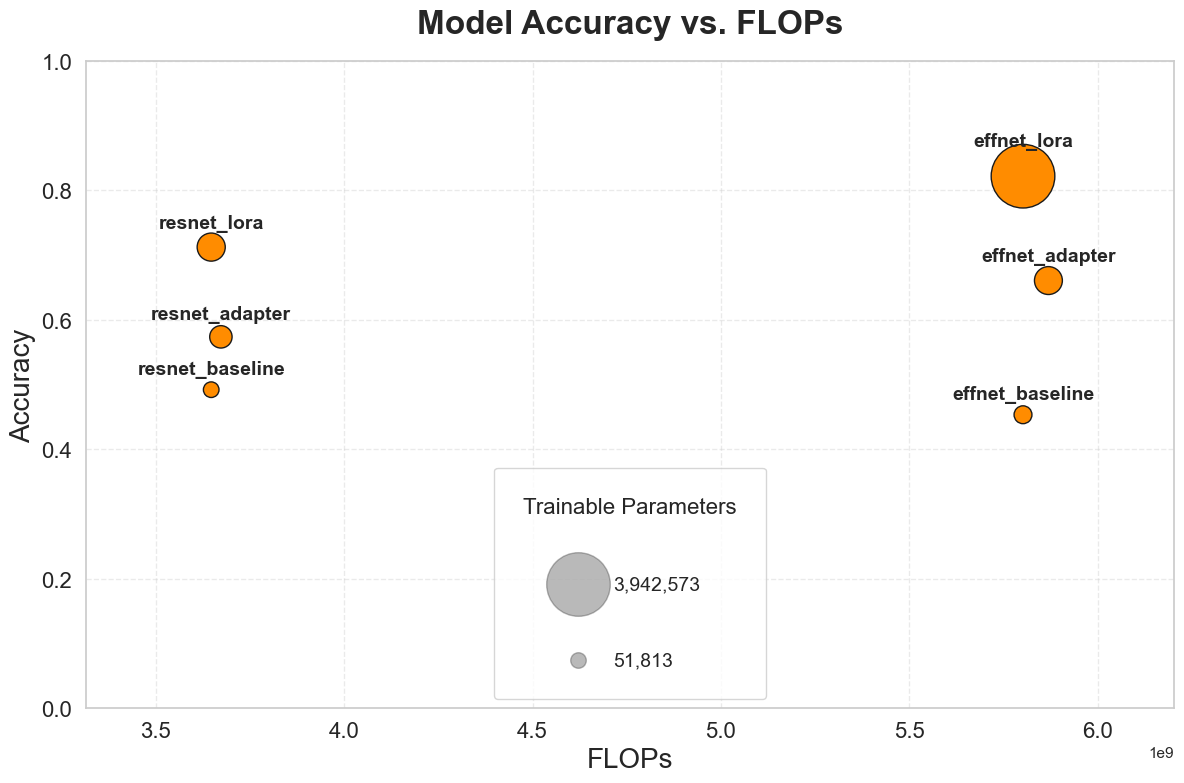

In [278]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

max_params = model_evaluations_aggregated['Trainable_Parameters'].max()
min_params = model_evaluations_aggregated['Trainable_Parameters'].min()

def get_size(p):
    return (p / max_params) * 2000 + 100

sizes = get_size(model_evaluations_aggregated['Trainable_Parameters'])

scatter = plt.scatter(
    model_evaluations_aggregated['FLOPs'], 
    model_evaluations_aggregated['Accuracy'], 
    s=sizes, 
    c="darkorange",
    edgecolors="k", 
    linewidth=1,
    zorder=2
)

for p in [max_params, min_params]:
    label = f'{int(p):,}' 
    plt.scatter([], [], c='k', alpha=0.3, s=get_size(p), label=f"{label}")

plt.legend(
    title="Trainable Parameters", 
    labelspacing=3, 
    borderpad=1.5,      
    frameon=True, 
    loc=8,
    fontsize=14,
    title_fontsize=16
)

for i in range(len(model_evaluations_aggregated)):
    y_offset = (sizes.iloc[i]**0.5) / 1500  
    
    plt.text(
        model_evaluations_aggregated['FLOPs'].iloc[i], 
        model_evaluations_aggregated['Accuracy'].iloc[i] + y_offset + 0.01, 
        model_evaluations_aggregated['Model'].iloc[i], 
        fontsize=14, 
        ha='center', 
        va='bottom', 
        fontweight='bold',
        zorder=3
    )

plt.xlabel('FLOPs', fontsize=20)
plt.ylabel('Accuracy', fontsize=20)
plt.title('Model Accuracy vs. FLOPs', fontsize=24, fontweight='bold', pad=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.4, zorder=1)

x_range = model_evaluations_aggregated['FLOPs'].max() - model_evaluations_aggregated['FLOPs'].min()
plt.xlim(model_evaluations_aggregated['FLOPs'].min() - (x_range * 0.15), model_evaluations_aggregated['FLOPs'].max() + (x_range * 0.15))
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig('plots/accuracy_vs_flops.png', dpi=300, bbox_inches='tight')
plt.show()

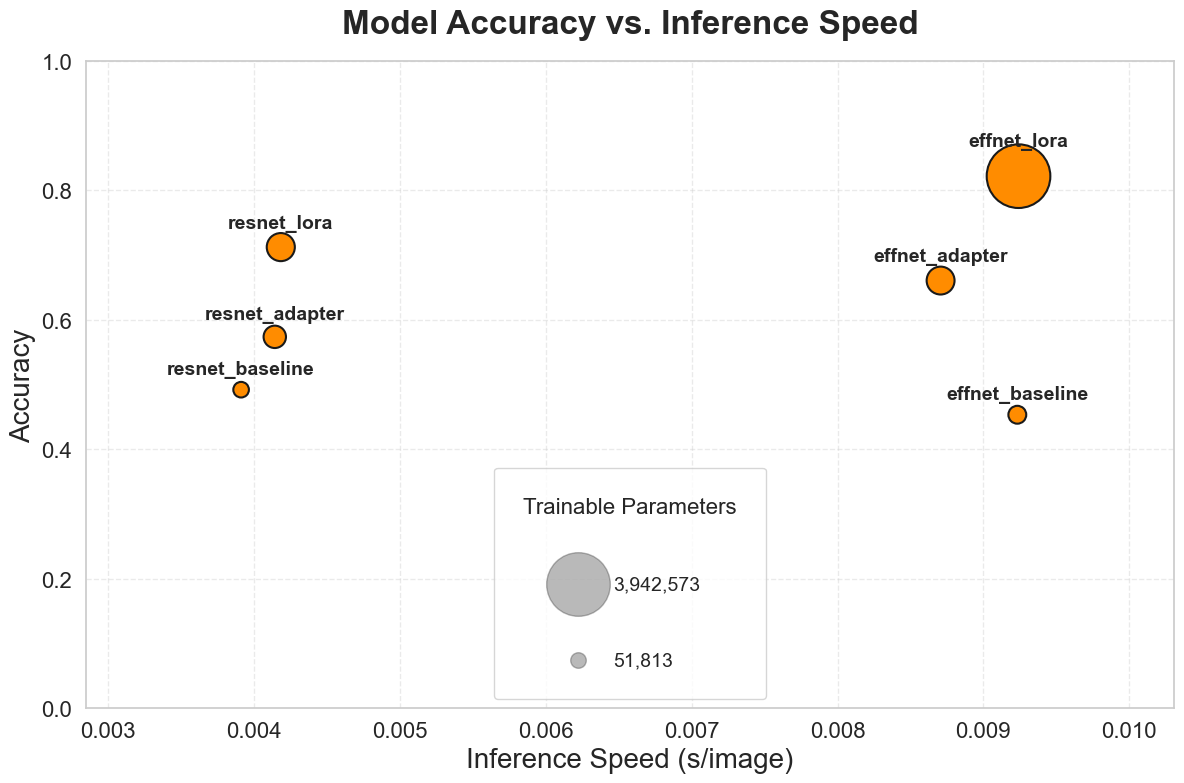

In [279]:
plt.figure(figsize=(12, 8))

max_params = model_evaluations_aggregated['Trainable_Parameters'].max()
min_params = model_evaluations_aggregated['Trainable_Parameters'].min()

def get_size(p):
    return (p / max_params) * 2000 + 100

sizes = get_size(model_evaluations_aggregated['Trainable_Parameters'])

scatter = plt.scatter(
    model_evaluations_aggregated['Speed'], 
    model_evaluations_aggregated['Accuracy'], 
    s=sizes, 
    c="darkorange",
    edgecolors="k", 
    linewidth=1.5,
    zorder=2
)

for p in [max_params, min_params]:
    label = f'{int(p):,}' 
    plt.scatter([], [], c='k', alpha=0.3, s=get_size(p), label=f"{label}")

plt.legend(
    title="Trainable Parameters", 
    labelspacing=3, 
    borderpad=1.5,      
    frameon=True, 
    loc=8,
    fontsize=14,
    title_fontsize=16
)

for i in range(len(model_evaluations_aggregated)):
    y_offset = (sizes.iloc[i]**0.5) / 1500  
    
    plt.text(
        model_evaluations_aggregated['Speed'].iloc[i], 
        model_evaluations_aggregated['Accuracy'].iloc[i] + y_offset + 0.01, 
        model_evaluations_aggregated['Model'].iloc[i], 
        fontsize=14, 
        ha='center', 
        va='bottom', 
        fontweight='bold',
        zorder=3
    )
    
plt.xlabel('Inference Speed (s/image)', fontsize=20)
plt.ylabel('Accuracy', fontsize=20)
plt.title('Model Accuracy vs. Inference Speed', fontsize=24, fontweight='bold', pad=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.4, zorder=1)

x_range = model_evaluations_aggregated['Speed'].max() - model_evaluations_aggregated['Speed'].min()
plt.xlim(model_evaluations_aggregated['Speed'].min() - (x_range * 0.2), model_evaluations_aggregated['Speed'].max() + (x_range * 0.2))
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig('plots/accuracy_vs_speed.png', dpi=300, bbox_inches='tight')
plt.show()

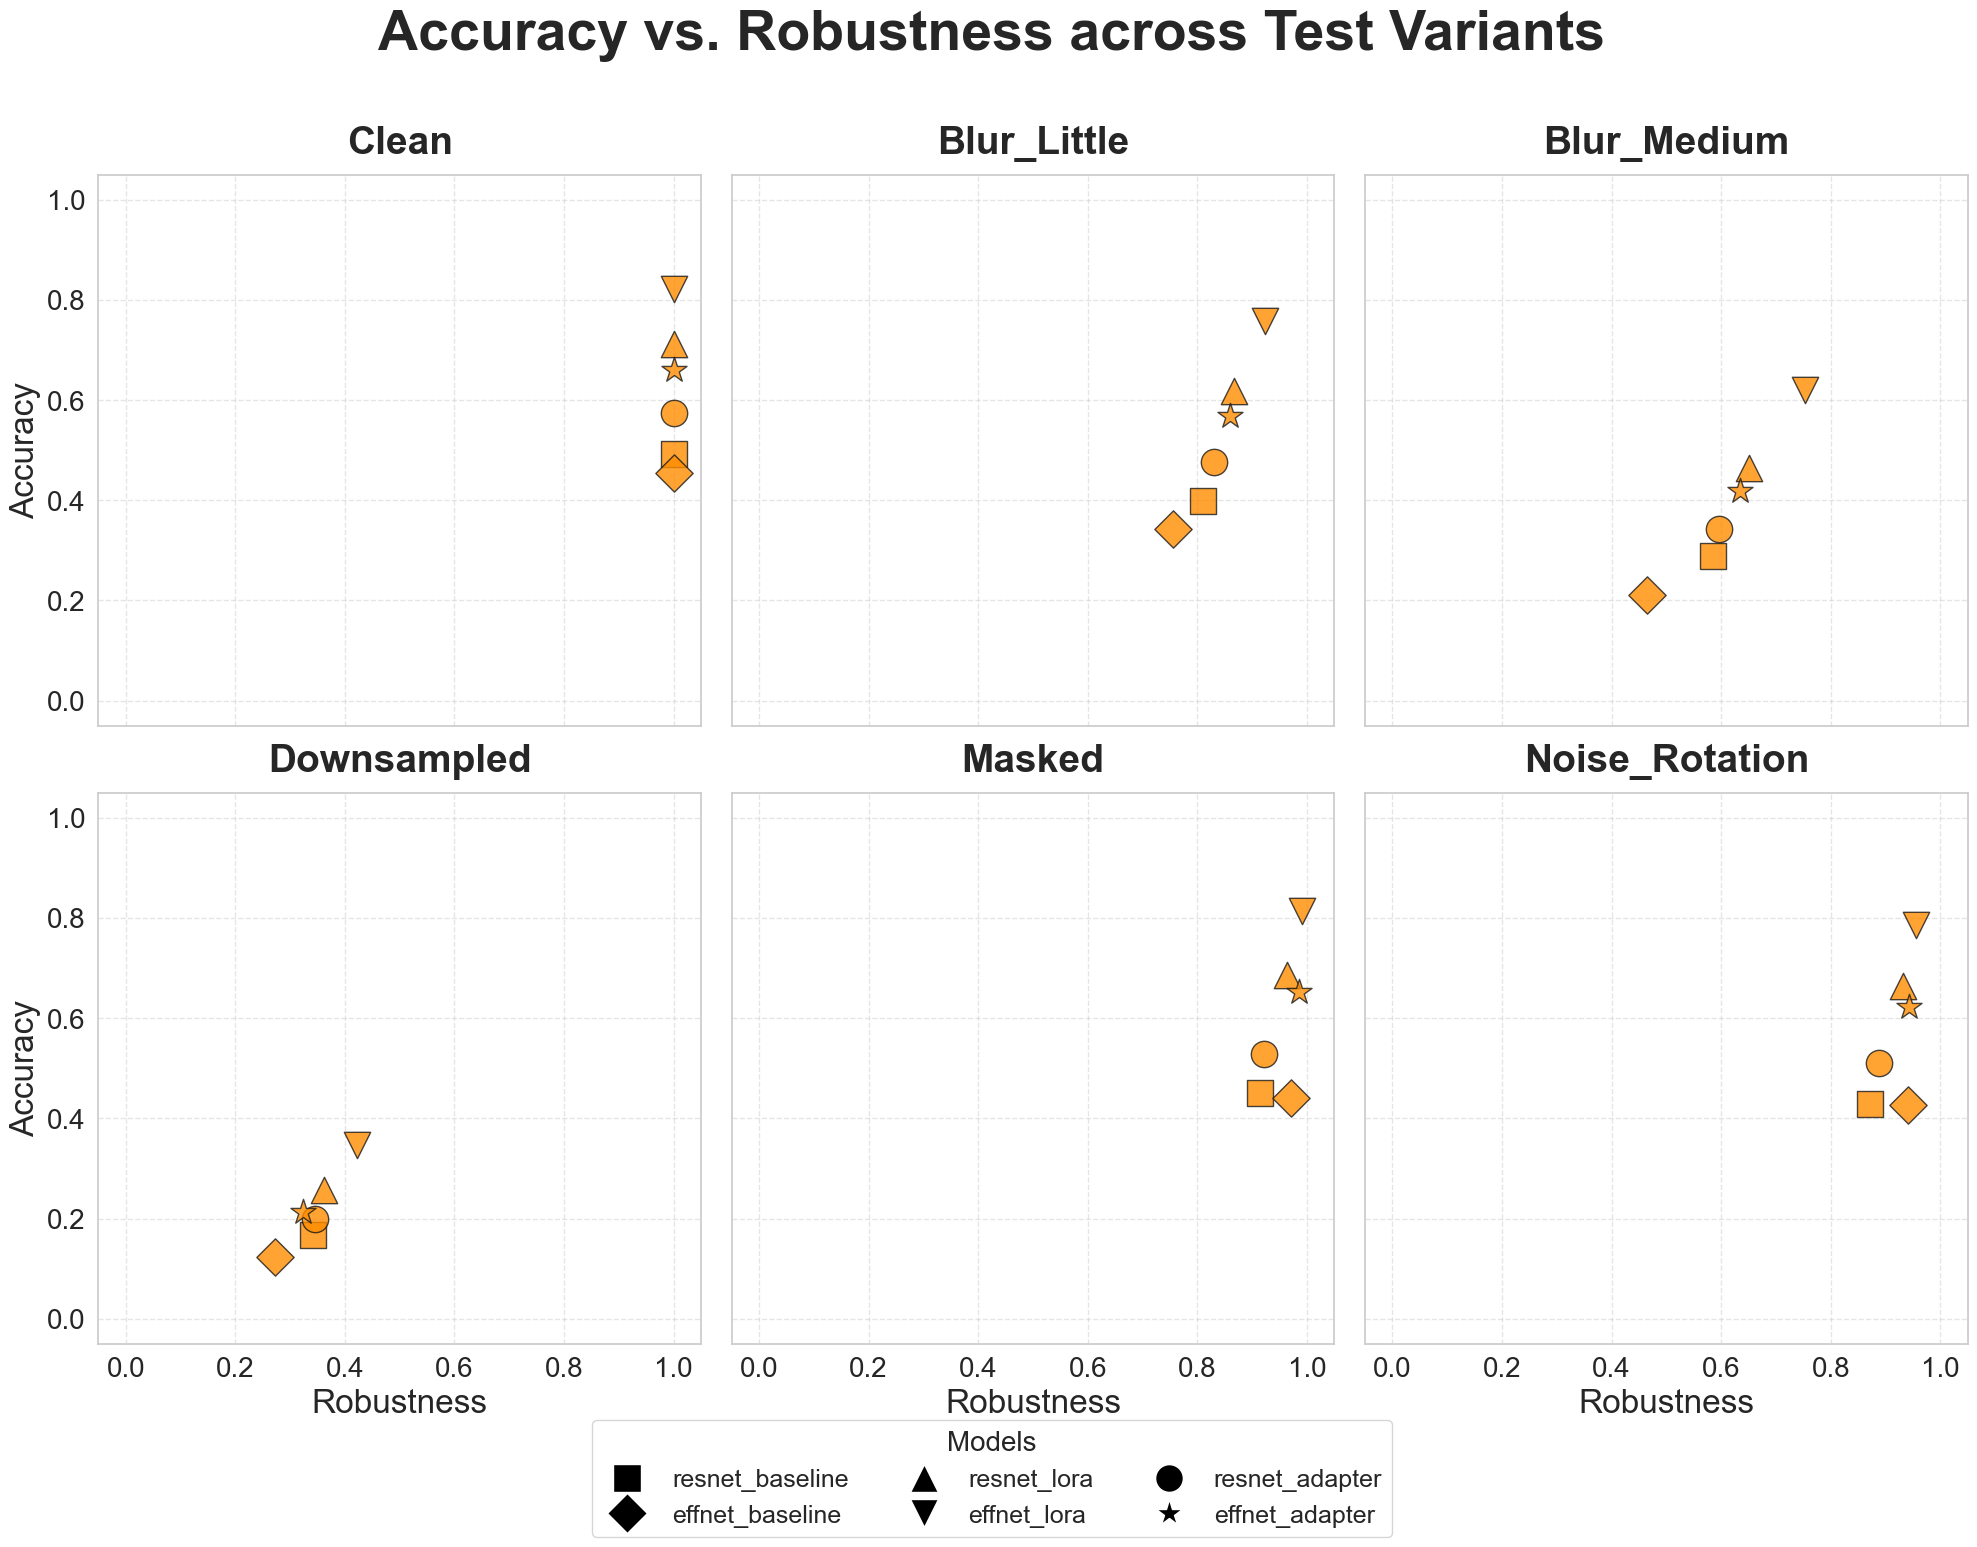

In [280]:
fig, axes = plt.subplots(2, 3, figsize=(20, 14), sharex=True, sharey=True)
axes = axes.flatten()

models = model_evaluations_all['Model'].unique()
datasets = model_evaluations_all['Dataset'].unique()

markers = ['s', 'D', '^', 'v', 'o', '*']
model_markers = dict(zip(models, markers))
fixed_size = 360

for i, dataset in enumerate(datasets):
    ax = axes[i]
    subset = model_evaluations_all[model_evaluations_all['Dataset'] == dataset]
    
    for model in models:
        row = subset[subset['Model'] == model]
        if not row.empty:
            ax.scatter(
                row['Robustness'], 
                row['Accuracy'], 
                s=fixed_size, 
                c='darkorange', 
                edgecolors="k", 
                linewidth=1,
                alpha=0.8,
                marker=model_markers[model]
            )

    ax.set_title(dataset, fontsize=28, fontweight='bold', pad=15)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    
    ax.tick_params(axis='both', which='major', labelsize=20)

    if i >= 3: 
        ax.set_xlabel('Robustness', fontsize=24)
    if i % 3 == 0: 
        ax.set_ylabel('Accuracy', fontsize=24)

legend_elements = [
    plt.Line2D([0], [0], marker=marker, color='w', label=model,
               markerfacecolor='black', markersize=20)
    for model, marker in model_markers.items()
]

fig.legend(
    handles=legend_elements, 
    loc='lower center', 
    ncol=3, 
    bbox_to_anchor=(0.5, -0.08), 
    fontsize=18, 
    title="Models",
    title_fontsize=20,
    frameon=True
)

plt.suptitle('Accuracy vs. Robustness across Test Variants', fontsize=40, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/accuracy_vs_robustness.png', dpi=300, bbox_inches='tight')
plt.show()

In [281]:
import os
import pandas as pd

results = []
eval_dir = 'evaluations'

for file in os.listdir(eval_dir):
    if file.endswith('_history.csv'):
        
        parts = file.split('_')
        model_name = f"{parts[0]}_{parts[1]}"
        
        path = os.path.join(eval_dir, file)
        history_df = pd.read_csv(path)
        
        val_accs = history_df['valid_accuracy'].iloc[:5].tolist()
        
        results.append([model_name] + val_accs)

columns = ['model_name', 'epoch_1', 'epoch_2', 'epoch_3', 'epoch_4', 'epoch_5']
training_history_summary = pd.DataFrame(results, columns=columns)

print(training_history_summary)

        model_name   epoch_1   epoch_2   epoch_3   epoch_4   epoch_5
0  resnet_baseline  0.274376  0.395208  0.439446  0.474059  0.492000
1      resnet_lora  0.567446  0.645782  0.674851  0.699644  0.712238
2      effnet_lora  0.708238  0.768554  0.798891  0.812792  0.821782
3   resnet_adapter  0.397624  0.488792  0.537386  0.559604  0.573624
4   effnet_adapter  0.467287  0.556356  0.608950  0.640990  0.660554
5  effnet_baseline  0.339129  0.388158  0.417307  0.437188  0.453307


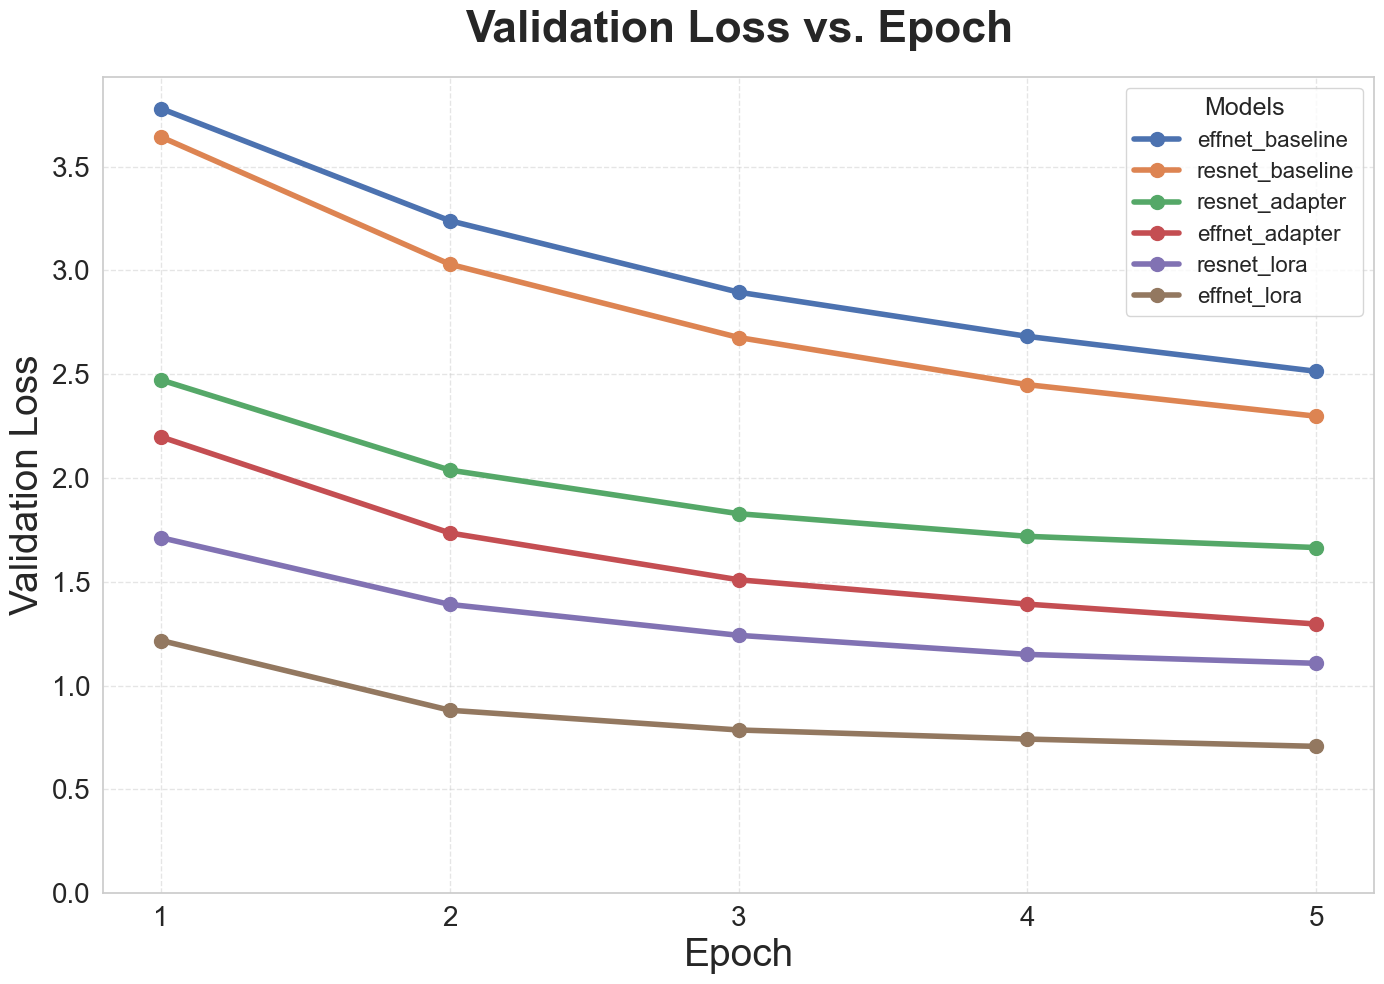

In [282]:
import os
import pandas as pd
import matplotlib.pyplot as plt

results = []
eval_dir = 'evaluations'

for file in os.listdir(eval_dir):
    if file.endswith('_history.csv'):
        parts = file.split('_')
        model_name = f"{parts[0]}_{parts[1]}"
        
        path = os.path.join(eval_dir, file)
        history_df = pd.read_csv(path)
        
        val_losses = history_df['valid_loss'].iloc[:5].tolist()
        results.append([model_name] + val_losses)

columns = ['model_name', 'epoch_1', 'epoch_2', 'epoch_3', 'epoch_4', 'epoch_5']
loss_history_summary = pd.DataFrame(results, columns=columns)

loss_history_summary = loss_history_summary.sort_values('epoch_5', ascending=False)

plt.figure(figsize=(14, 10))
epochs = [1, 2, 3, 4, 5]

for _, row in loss_history_summary.iterrows():
    plt.plot(
        epochs, 
        row[1:], 
        marker='o', 
        markersize=10, 
        linewidth=4, 
        label=row['model_name']
    )

plt.title('Validation Loss vs. Epoch', fontsize=32, fontweight='bold', pad=25)
plt.xlabel('Epoch', fontsize=28)
plt.ylabel('Validation Loss', fontsize=28)
plt.xticks(epochs, fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(fontsize=16, title="Models", title_fontsize=18, loc='upper right')

plt.ylim(bottom=0) 
plt.tight_layout()
plt.savefig('plots/loss_vs_epoch.png', dpi=300, bbox_inches='tight')
plt.show()